In [1]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn

Load the file and split into grains for analysis

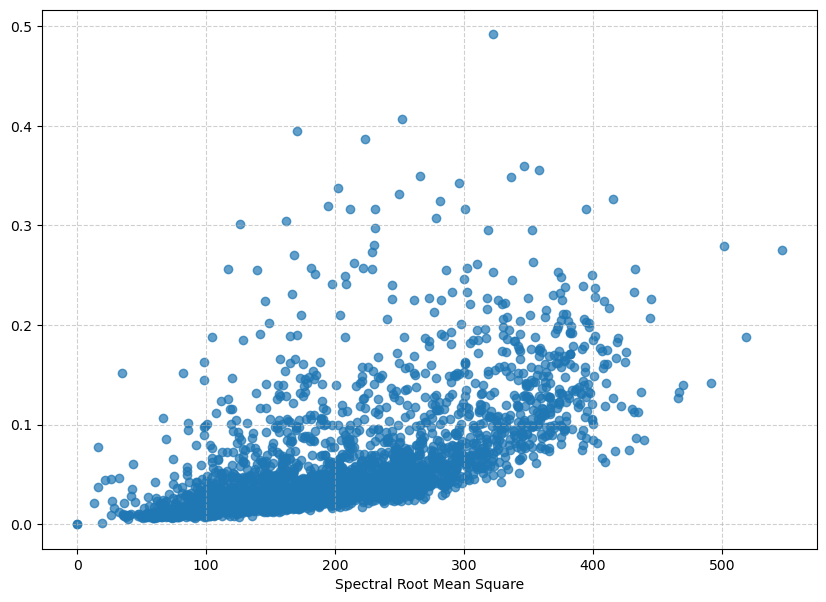

In [ ]:
sr=48000
y, sr = af.read("..\..\corpus\piano_sample_1\input.wav", samplate=sr) # sr is 48kHz

grain_duration = 0.1 # in s
grain_size = int(grain_duration * sr)
n_grains_in_source = int(len(y) // grain_size)
grains = [i*grain_size for i in range(n_grains_in_source)]

# since BFT is based on the FFT, the number of bins needs to be half that of a power of 2
bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=grain_size,
               data_type=af.type.SpectralDataType.MAG,
               scale_type=af.type.SpectralFilterBankScaleType.LINEAR)
spec_arr = bft_obj.bft(y)
spec_arr = np.abs(spec_arr)
spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
n_time = spec_arr.shape[-1]  
spectral_obj.set_time_length(n_time)
rms_arr = spectral_obj.rms(spec_arr)
centroid_arr = spectral_obj.crest(spec_arr)

n_clusters=4
x = np.array([[i, j] for i, j in zip(rms_arr, centroid_arr)])
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters, n_init='auto', random_state=0).fit(x)
plt.figure(figsize=(10, 7))
plt.scatter(centroid_arr, rms_arr, alpha=0.7)
# plt.ylabel()
plt.xlabel("Spectral Root Mean Square")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

dict_clusters = {}
for idx, lab in enumerate(kmeans.labels_):
    dict_clusters[lab] = dict_clusters.get(lab, [])
    dict_clusters[lab].append(idx)


In [ ]:
frequency_matrix = np.zeros((n_clusters, n_clusters))
labels = kmeans.labels_
prev_label = labels[0]
for label_idx in range(1, len(labels)):
    frequency_matrix[prev_label][labels[label_idx]] += 1
    prev_label = labels[label_idx]
total_freq = np.sum(frequency_matrix)

probability_matrix = []#np.zeros((n_clusters, n_clusters))
for i in frequency_matrix:
    row = i / np.sum(i)
    probability_matrix.append(row)
transition_matrix_fin = np.array(probability_matrix)
transition_matrix_fin

array([[0.67450059, 0.23854289, 0.06698002, 0.0199765 ],
       [0.10946746, 0.64891519, 0.05029586, 0.1913215 ],
       [0.30405405, 0.01576577, 0.66891892, 0.01126126],
       [0.03483146, 0.16516854, 0.04382022, 0.75617978]])

This section of the notebook concerns actual synthesis

In [ ]:
output_buffer = np.array([]) 
curr_label = 3
n_iterations = 100
seed = 100
s = np.random.seed(seed)

for i in range(n_iterations):

    next_label = np.random.choice(range(n_clusters), p=transition_matrix_fin[curr_label])
    grain_idx = np.random.choice(dict_clusters[next_label]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    output_buffer = np.concatenate([output_buffer, grain])
    curr_label = next_label
# output_buffer / np.max(np.abs(output_buffer))
sf.write(f"..\..\corpus\piano_sample_1\output\mm_{n_iterations}_{grain_size}_{sr}_{curr_label}.wav", output_buffer, samplerate=sr)

0
0
1
1
1
1
1
1
1
0
2
0
1
1
3
3
1
1
1
1
1
1
1
1
3
3
3
1
0
0
1
0
1
1
1
0
1
1
1
1
0
0
0
0
0
0
1
1
0
0
0
0
0
0
2
2
2
0
0
0
0
0
0
0
0
0
0
1
1
3
3
0
0
2
0
0
2
2
2
2
2
2
2
2
2
2
0
0
0
3
3
3
3
3
2
2
0
0
0
0


In [ ]:
import analysis
dir = "../../corpus/piano_sample_1/"
sr = 48000
analyzer = analysis.AnalysisObject(dir, sr)
